In [1]:
# Imports
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import mlflow
import numpy as np

sys.path.insert(0, str(Path('..').resolve()))

In [2]:
# Parameters
TRACKING_URI = 'sqlite:///mlflow.db'
EXPERIMENT_NAME = 'mlruns-ml-100k'
#EXPERIMENT_NAME = 'mlruns-ml-10m'

# Metrics to plot: key -> subplot title
METRICS = {
    'train_bpr_loss': 'Train BPR Loss',
    'bpr_loss':       'Test BPR Loss',
    'auc':            'AUC',
    'ndcg_20':        'NDCG@20',
    'precision_20':   'Precision@20',
    'recall_20':      'Recall@20',
}

In [3]:
# List all finished/running runs for the experiment
from hybridbpr.plotter import MLflowPlotter

plotter = MLflowPlotter(TRACKING_URI)
runs_df = plotter.get_runs(experiment_name=EXPERIMENT_NAME)
client = plotter.client

mask = runs_df['status'].isin(['FINISHED', 'RUNNING'])
print(runs_df.loc[mask, ['status', 'run_name']].to_string(index=False))

  status                                 run_name
 RUNNING      ml-100k_neg_nl128_featboth_lr0.0001
 RUNNING       ml-100k_neg_nl128_featboth_lr0.001
 RUNNING ml-100k_neg_nl128_featindicator_lr0.0001
 RUNNING  ml-100k_neg_nl128_featindicator_lr0.001
 RUNNING   ml-100k_neg_nl128_featindicator_lr0.01
 RUNNING  ml-100k_neg_nl128_featmetadata_lr0.0001
 RUNNING   ml-100k_neg_nl128_featmetadata_lr0.001
 RUNNING        ml-100k_neg_nl64_featboth_lr0.001
 RUNNING    ml-100k_neg_nl64_featindicator_lr0.01
 RUNNING    ml-100k_neg_nl64_featmetadata_lr0.001
 RUNNING       ml-100k_neg_nl32_featboth_lr0.0001
 RUNNING        ml-100k_neg_nl32_featboth_lr0.001
 RUNNING         ml-100k_neg_nl32_featboth_lr0.01
 RUNNING  ml-100k_neg_nl32_featindicator_lr0.0001
 RUNNING    ml-100k_neg_nl32_featindicator_lr0.01
 RUNNING   ml-100k_neg_nl32_featmetadata_lr0.0001
 RUNNING    ml-100k_neg_nl32_featmetadata_lr0.001
 RUNNING     ml-100k_neg_nl32_featmetadata_lr0.01
FINISHED          ml-100k_nl128_featboth_lr0.0001


<bound method MLflowPlotter.get_experiments of <hybridbpr.plotter.MLflowPlotter object at 0x7fbfb5a768b0>>

In [4]:
# plot_runs: fetch histories and plot for a given label->run_name dict
exp_id = plotter.client.get_experiment_by_name(
    EXPERIMENT_NAME
).experiment_id

def plot_runs(runs: dict[str, str], title: str = '') -> None:
    """Plot METRICS for each named run on a 3x2 subplot grid."""
    # Resolve run names to IDs
    run_ids: dict[str, str] = {}
    for label, run_name in runs.items():
        results = client.search_runs(
            experiment_ids=[exp_id],
            filter_string=f"attributes.run_name = '{run_name}'",
            max_results=1,
        )
        if not results:
            print(f'WARNING: run not found: {run_name}')
            continue
        run_ids[label] = results[0].info.run_id

    # Fetch metric histories
    histories: dict[str, dict] = {}
    for label, run_id in run_ids.items():
        histories[label] = {}
        for key in METRICS:
            hist = client.get_metric_history(run_id, key)
            histories[label][key] = (
                [m.step for m in hist],
                [m.value for m in hist],
            )

    # Plot 3x2 grid
    metric_items = list(METRICS.items())
    n_cols = 2
    n_rows = int(np.ceil(len(metric_items) / n_cols))
    fig, axes = plt.subplots(
        n_rows, n_cols, figsize=(14, n_rows * 4), squeeze=False
    )
    for idx, (metric_key, metric_label) in enumerate(metric_items):
        row, col = divmod(idx, n_cols)
        ax = axes[row][col]
        for i, (label, hist) in enumerate(histories.items()):
            steps, vals = hist.get(metric_key, ([], []))
            if steps:
                ax.plot(
                    steps, vals, label=label,
                    color=f'C{i}', linewidth=2,
                )
        ax.set_xlabel('Epoch')
        ax.set_ylabel(metric_label)
        ax.set_title(metric_label)
        ax.legend(loc='best', fontsize=9)
        ax.grid(True, alpha=0.3)

    # Hide unused subplots
    for idx in range(len(metric_items), n_rows * n_cols):
        row, col = divmod(idx, n_cols)
        axes[row][col].set_visible(False)

    if title:
        fig.suptitle(title, fontsize=12, y=1.01)
    fig.tight_layout()
    plt.show()

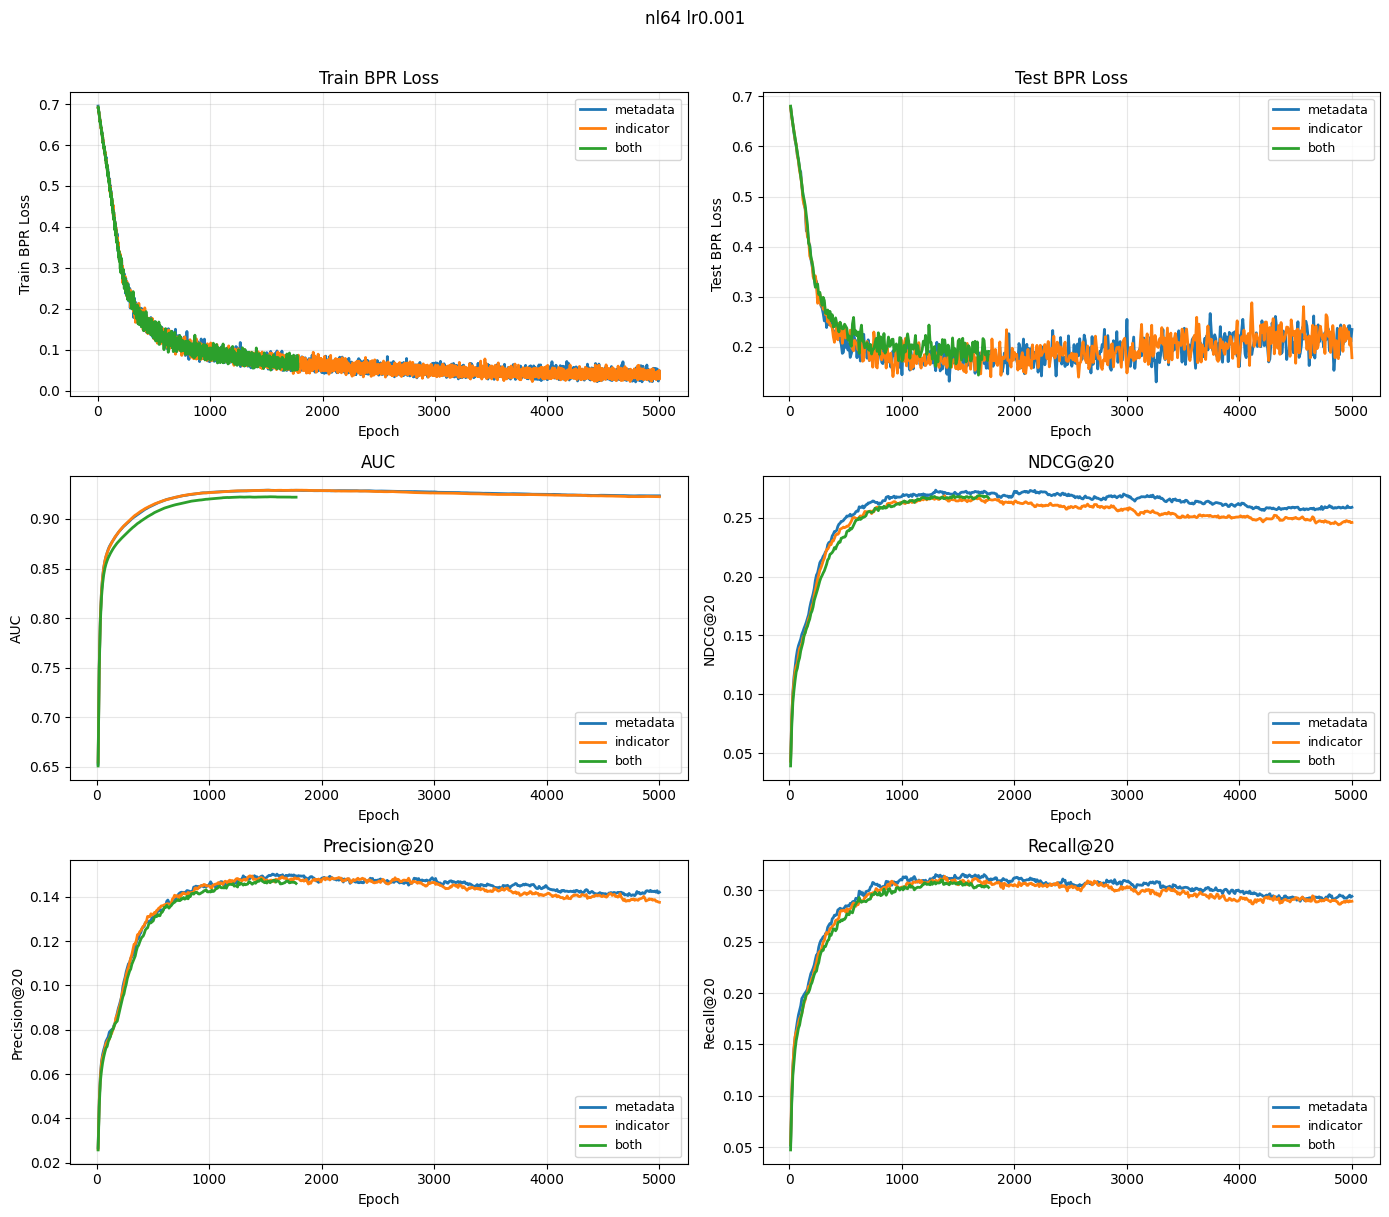

In [9]:
plot_runs({
    'metadata':  'ml-100k_nl32_featmetadata_lr0.001',
    'indicator': 'ml-100k_nl32_featindicator_lr0.001',
    'both':      'ml-100k_nl32_featboth_lr0.001',
}, title='nl64 lr0.001')

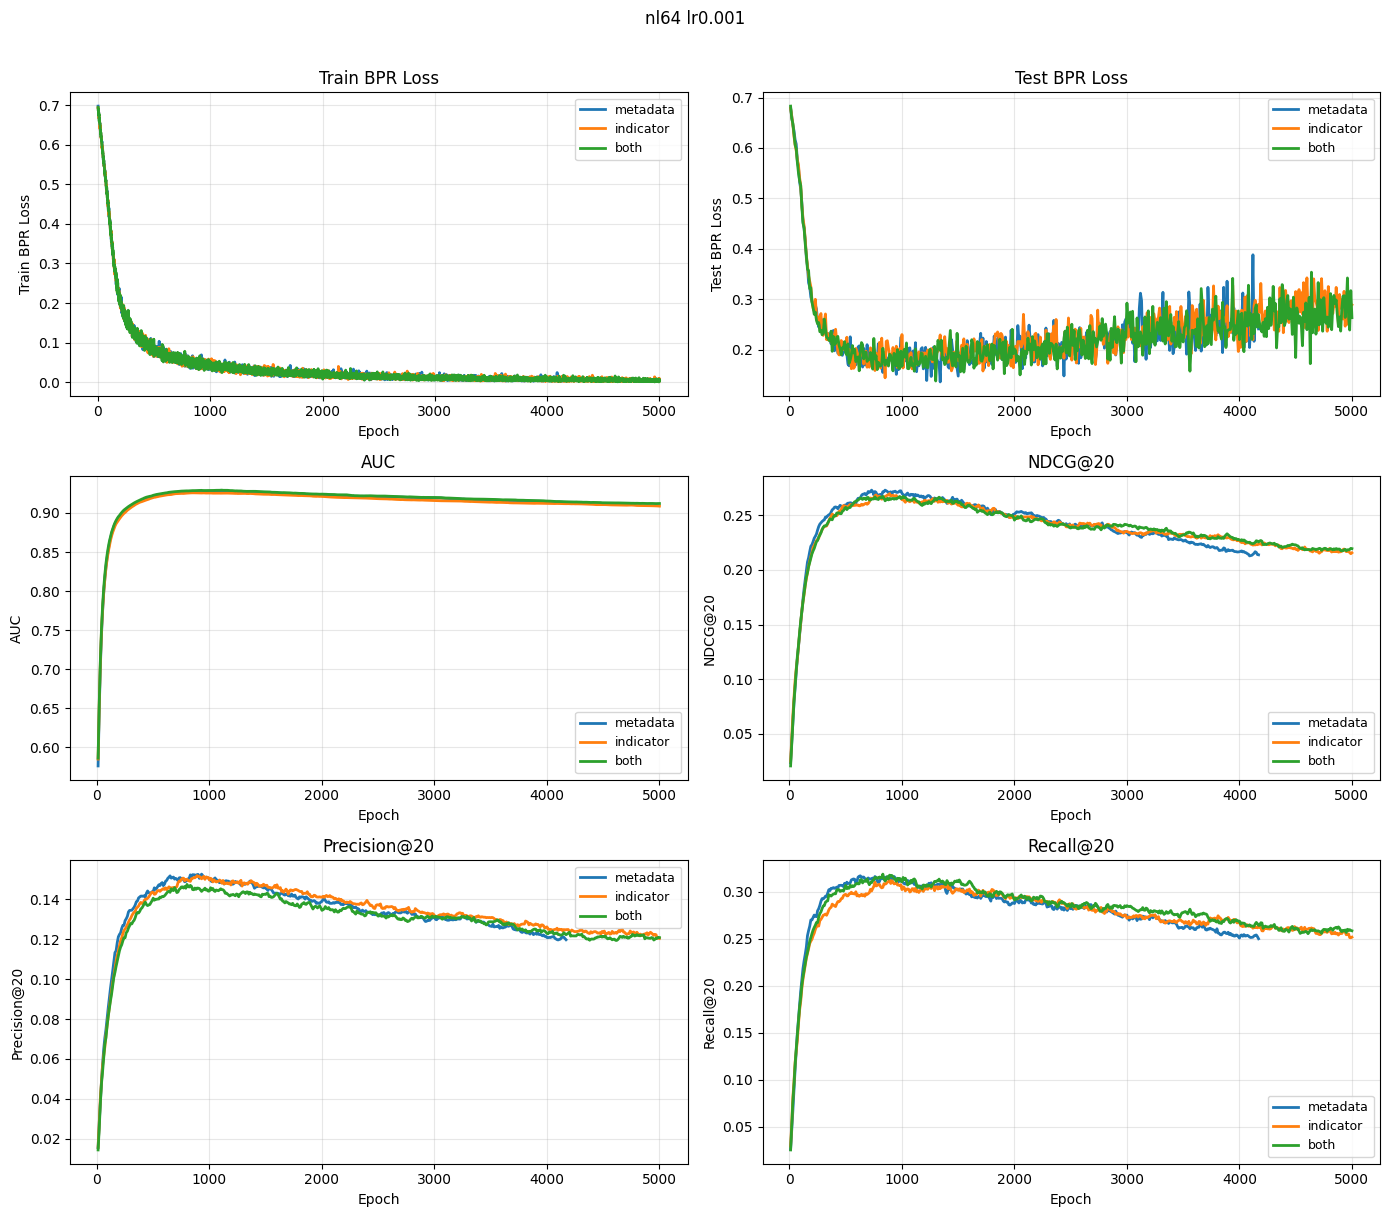

In [37]:
plot_runs({
    'metadata':  'ml-100k_nl128_featmetadata_lr0.001',
    'indicator': 'ml-100k_nl128_featindicator_lr0.001',
    'both':      'ml-100k_nl128_featboth_lr0.001',
}, title='nl64 lr0.001')

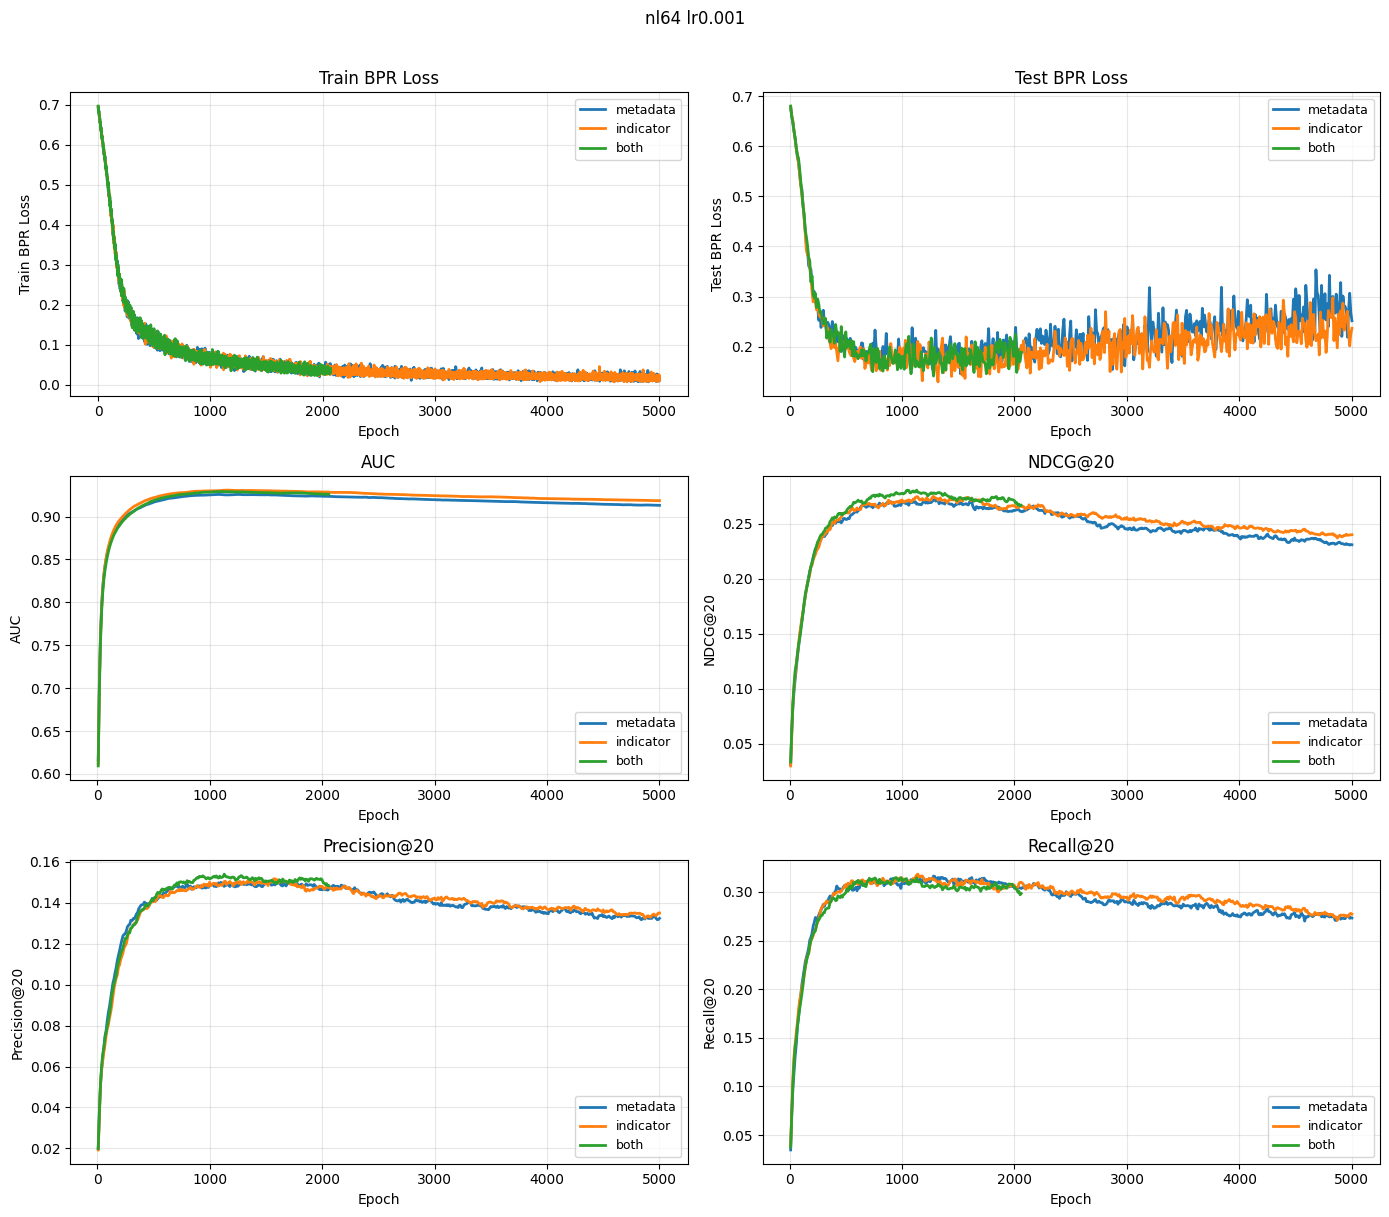

In [6]:
plot_runs({
    'metadata':  'ml-100k_nl64_featmetadata_lr0.001',
    'indicator': 'ml-100k_nl64_featindicator_lr0.001',
    'both':      'ml-100k_nl64_featboth_lr0.001',
}, title='nl64 lr0.001')

/tmp/ipykernel_2845121/2650231374.py:52: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(loc='best', fontsize=9)


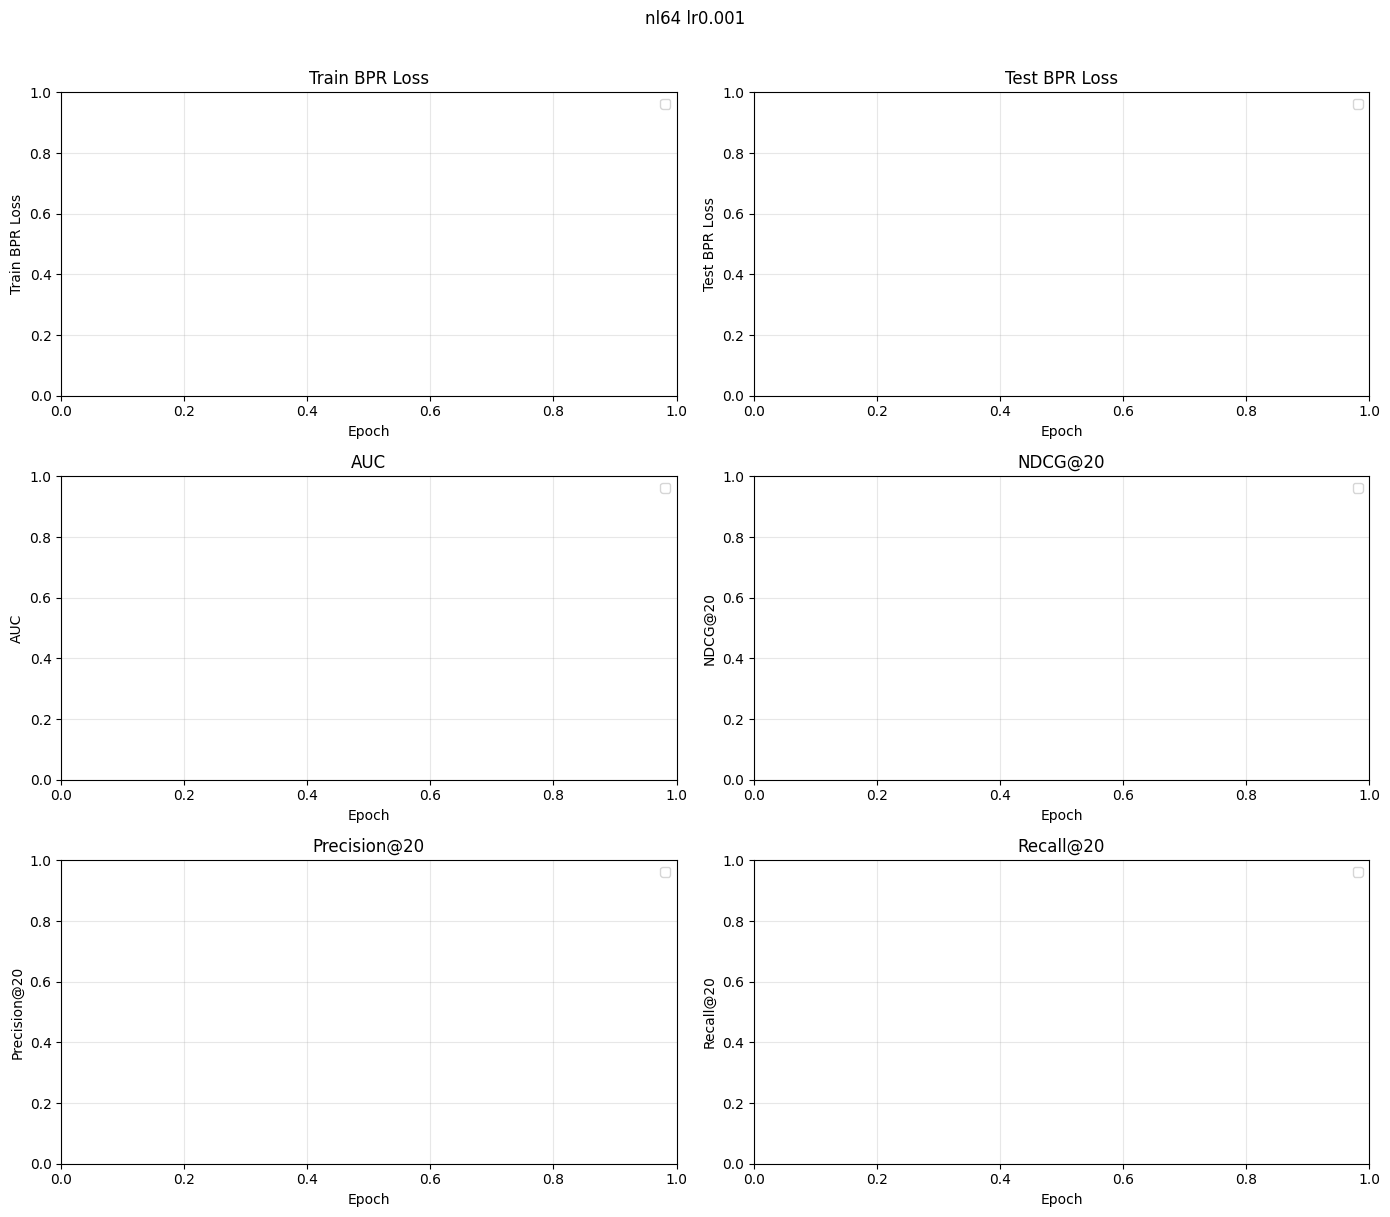

In [7]:
plot_runs({
    'metadata':  'ml-10m_neg_nl64_featmetadata_lr0.0001',
    'indicator': 'ml-10m_neg_nl64_featindicator_lr0.0001',
    'both':      'ml-10m_neg_nl64_featboth_lr0.0001',
}, title='nl64 lr0.001')

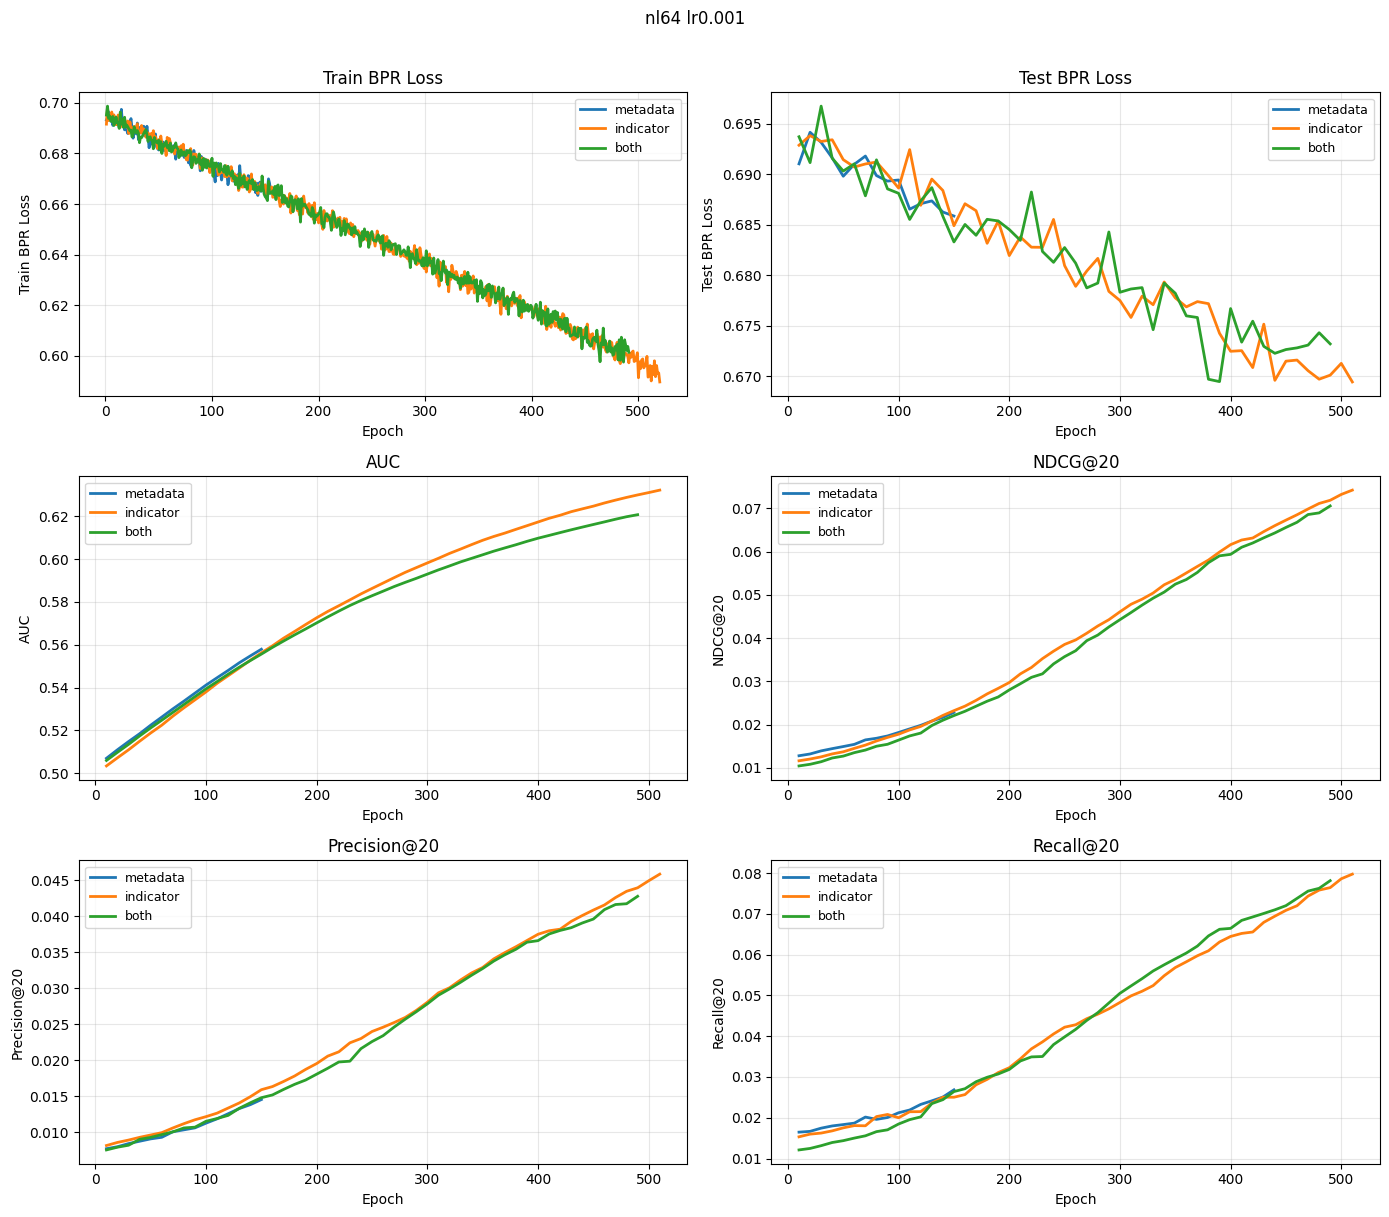

In [21]:
plot_runs({
    'metadata':  'ml-100k_neg_nl64_featmetadata_lr0.0001',
    'indicator': 'ml-100k_neg_nl64_featindicator_lr0.0001',
    'both':      'ml-100k_neg_nl64_featboth_lr0.0001',
}, title='nl64 lr0.001')